**UNDERFUNDING AND THE UK EDUCATIONAL SYSTEM**

In the last 15 years, the UK educational system has been hit with budget cuts that have severly affected the quality of education being offered to its students. In clear terms, schools can no longer operate on the standard they used to years ago being able to afford the same essential operational costs they could in the 2010's (https://schoolcuts.org.uk/about/).
According to new research released by the school cuts coalition group about 76% of primary schools and over 95% of secondary schools will not be able to afford their costs next year. While school cuts are expected to rise by about 3.4% in the year to come, mainstream funding is expected to jump by a miserly 2.2% which leaves a £700 million deficit to the government in order to achieve optimum funding (https://neu.org.uk/latest/press-releases/vast-majority-schools-face-funding-cuts-next-year?utm_source=chatgpt.com).

<img src="image.png" alt="Image 1"/>

While the numbers provide a bird eye view of the effects of budget cuts, it becomes necessary to dig in deeper to understand how underfunding has affected the quality of staff and ultimately the learning experience of pupils and students in communities especially those that rely heavily on governemnt funding to function efficiently. According to reports from the Guardian, as of April 2024, 51% of secondary schools in England have cut teaching staff due to financial pressures, up from 38% the previous year (https://www.theguardian.com/education/2025/apr/10/england-secondary-schools-staff-budget-cuts?utm_source=chatgpt.com).

Alongside staff cuts, an increasing number of secondary school leaders have had to reduce the number of GCSE subjects offered to save money. Budget constraints have also led to cuts in extracurricular activities, cancelled school trips, and reduced investment in IT equipment and infrastructure. Primary schools seem to have been hit the hardest due to noticeable drops in per pupil funding (https://www.theguardian.com/education/2024/apr/19/english-primary-schools-cutting-teacher-numbers-amid-budget-pressure-survey-finds?utm_source=chatgpt.com).

To meet basic running costs, schools have been forced to divert Pupil Premium funding—originally allocated to support disadvantaged students. This, of course, gravely affects pupils with special educational needs and disabilities (SEND), who often rely on targeted support and interventions that are now being scaled back or removed entirely.



In this study, we examine the impact of underfunding and budget cuts on the academic performance of primary school pupils in the UK. Using Key Stage 2 (KS2) attainment as our core performance metric, we explore the relationship between funding levels and pupil outcomes across a range of schools with varying socioeconomic profiles. We focus on data from the 2023/2024 academic session to understand and hypothesize how better funding can elevate the learning experience and quality of education being offered to pupils in UK communities.

Data was gathered from two sources:
* Schools' Funding data: https://explore-education-statistics.service.gov.uk/find-statistics/school-funding-statistics/2024-25

* Ks2 attainment data: https://www.compare-school-performance.service.gov.uk/

Because funding encompasses a large range of sectors, for the sake of this study, funding options will be locked down to:
* pupil premiums
* meal allocations (FSM and UIFSM)
* family income(IDACI)
* teacher grants
* pe and sports premium
* basic entitlement

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [2]:
#Read in school funding data and ks2 data 
school_funding_data=pd.read_csv('data\school_data.csv')
ks2_data=pd.read_csv('data\ks2_data.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\3118405039.py:3: DtypeWarning: Columns (278,279) have mixed types. Specify dtype option on import or set low_memory=False.
  ks2_data=pd.read_csv('data\ks2_data.csv')


In [3]:
#View first five rows
school_funding_data.head()

,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,new_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,basic_entitlement_ks3,basic_entitlement_ks4,basic_entitlement_total_funding,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,deprivation_total_funding,eal_total_funding,mobility_total_funding,prior_attainment_total_funding,lump_sum_total_funding,sparsity_total_funding,london_fringe,split_site_total_funding,national_non_domestic_rates_funding,pfi_total_funding,exceptional_factors_total_funding,minimum_per_pupil_funding,total_schools_block_allocation_(pre_mfg),mfg_protection_or_capping_scaling,total_schools_block_allocation_(post_mfg),notional_sen,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,coronavirus_recovery_premium_funding,teachers_pay_additional_grant,mainstream_schools_additional_grant,national_tutoring_programme,total_funding
0,202324,Financial year,School,E92000001,England,301,E09000002,Barking and Dagenham,10000222,101247,3014703,All Saints Catholic School and Technology College,Voluntary aided school,Secondary,z,No,0,3716479,2792472,6508951,137924,350943,87965,224591,125448,90436,21575,1057,551072,1039940,38984,0,422623,145251,0,0,0,0,0,0,0,8155748,0,8155748,667057,1170,6970.724786,309465,299,z,z,z,82524,86830,291208,20587.5,8946362.5
1,202324,Financial year,School,E92000001,England,301,E09000002,Barking and Dagenham,10000527,101241,3014021,"Barking Abbey School, A Specialist Sports and ...",Community school,Secondary,z,No,0,5828837,4302077,10130914,227680,578561,79832,126747,191368,163588,5799,0,567334,1373575,79916,0,659132,145251,0,0,200000,438864,0,0,0,13027653,0,13027653,1062253,1822,7150.193743,508185,491,z,z,z,164173,135702,455155,33412.5,14324280.5
2,202324,Financial year,School,E92000001,England,301,E09000002,Barking and Dagenham,10071309,101202,3012024,Beam Primary School,Community school,Primary,z,No,2250199,0,0,2250199,76801,120002,20097,126778,24466,9804,0,0,181145,377948,156015,14202,254174,145251,0,0,0,64372,0,0,0,3262160,0,3262160,352575,564,5783.971631,216795,149,46128,20740,474,21605,29807,98865,9450,3705550.0
3,202324,Financial year,School,E92000001,England,301,E09000002,Barking and Dagenham,10071301,101231,3012068,Becontree Primary School,Community school,Primary,z,No,1687649,0,0,1687649,52835,81601,27666,46390,54424,4902,579,0,133961,268397,73062,7262,204432,145251,0,0,0,38304,0,0,0,2424357,0,2424357,271650,423,5731.340426,146955,101,33510,19610,361,18555,22359,74160,6817.5,2746323.5
4,202324,Financial year,School,E92000001,England,301,E09000002,Barking and Dagenham,10089864,148932,3014008,Brook Sixth Form and Academy,University technical college,Secondary,PARTNERSHIP LEARNING,Yes,0,0,161104,161104,4358,15195,2281,4545,3518,2315,0,0,12658,32210,5328,586,15283,145251,0,0,0,0,0,0,0,359763,0,359763,25059,27,13324.555560,13455,13,z,z,z,6000,3936,13182,877.5,397213.5


In [4]:
#Columns in school funding data
school_funding_data.columns

Index(['time_period', 'time_identifier', 'geographic_level', 'country_code',
       'country_name', 'old_la_code', 'new_la_code', 'la_name', 'school_ukprn',
       'school_urn', 'school_laestab', 'school_name', 'school_type',
       'school_phase', 'trust', 'academy', 'basic_entitlement_primary',
       'basic_entitlement_ks3', 'basic_entitlement_ks4',
       'basic_entitlement_total_funding', 'fsm_funding', 'fsm6_funding',
       'idaci_band_f', 'idaci_band_e', 'idaci_band_d', 'idaci_band_c',
       'idaci_band_b', 'idaci_band_a', 'idaci_funding',
       'deprivation_total_funding', 'eal_total_funding',
       'mobility_total_funding', 'prior_attainment_total_funding',
       'lump_sum_total_funding', 'sparsity_total_funding', 'london_fringe',
       'split_site_total_funding', 'national_non_domestic_rates_funding',
       'pfi_total_funding', 'exceptional_factors_total_funding',
       'minimum_per_pupil_funding', 'total_schools_block_allocation_(pre_mfg)',
       'mfg_protection_or_

To understand what each column means and what they represent:
Variable name                              |  Variable description
-----------------------------------------  |  ------------------------------------------------
academy                                    |  Academy?
allocation_per_pupil                       |  Allocation per Pupil
basic_entitlement_ks3                      |  Basic Entitlement KS3
basic_entitlement_ks4                      |  Basic Entitlement KS4
basic_entitlement_primary                  |  Basic Entitlement Primary
basic_entitlement_total_funding            |  Basic Entitlement Total Funding
coronavirus_recovery_premium_funding       |  Coronavirus (COVID-19) recovery premium funding
deprivation_total_funding                  |  Deprivation Total Funding
eal_total_funding                          |  EAL Total Funding
exceptional_factors_total_funding          |  Exceptional Factors Total Funding
fsm_funding                                |  FSM Funding
fsm6_funding                               |  FSM6 Funding
idaci_band_a                               |  IDACI Band A
idaci_band_b                               |  IDACI Band B
idaci_band_c                               |  IDACI Band C
idaci_band_d                               |  IDACI Band D
idaci_band_e                               |  IDACI Band E
idaci_band_f                               |  IDACI Band F
idaci_funding                              |  IDACI Funding
london_fringe                              |  London Fringe
lump_sum_total_funding                     |  Lump Sum Total Funding
mainstream_schools_additional_grant        |  Mainstream Schools Additional Grant
mfg_protection_or_capping_scaling          |  MFG protection (+ve) or capping/scaling (-ve)
minimum_per_pupil_funding                  |  Minimum per pupil funding
mobility_total_funding                     |  Mobility Total Funding
national_non_domestic_rates_funding        |  National Non Domestic Rates Funding
national_tutoring_programme                |  National Tutoring Programe Funding
notional_sen                               |  Notional SEN
pe_&_sport_premium                         |  PE & Sport Premium funding
pe_&_sport_premium_pupils                  |  PE & Sport Premium pupils
pfi_total_funding                          |  PFI Total Funding
prior_attainment_total_funding             |  Prior Attainment Total Funding
pupil_premium                              |  Pupil Premium funding
pupil_premium_pupils                       |  Pupil Premium pupils
school_phase                               |  Phase
school_type                                |  School type
school_ukprn                               |  UKPRN
sparsity_total_funding                     |  Sparsity Total Funding
split_site_total_funding                   |  Split Site Total Funding
teachers_pay_additional_grant              |  Teachers' Pay Additional Grant
total_funding                              |  Total funding
total_number_of_pupils                     |  Total Number of Pupils (rounded)
total_schools_block_allocation_(post_mfg)  |  Total Schools Block Allocation (Post MFG)
total_schools_block_allocation_(pre_mfg)   |  Total Schools Block Allocation (Pre MFG)
trust                                      |  Trust
universal_infant_free_school_meals_grant   |  Universal Infant Free School Meals Grant funding

In [5]:
school_funding_data.shape

(20181, 57)

The dataset contains over 20 thousand rows of data for both primary and secondary schools for the 2023/2024 session. Since we are mostly interested in primary schools, we will select data for just primary schools which is our area of focus.

The column school phase in the dataset provides information on the school type. That is, whether its a primary or secondary school. We can explore the unique values in school phase

In [6]:
school_funding_data['school_phase'].value_counts()

school_phase
Primary                    16770
Secondary                   3150
All-through                  159
Middle deemed secondary       93
Middle deemed primary          8
Not applicable                 1
Name: count, dtype: int64

For our analysis, we will be considering schools that fall in the primary and middle deemed primary categories.

In [7]:
pry_school_funding_data=school_funding_data[(school_funding_data['school_phase']=='Primary') | (school_funding_data['school_phase']=='Middle deemed primary')]

In [8]:
pry_school_funding_data.shape

(16778, 57)

Our dataframe of focus contains over 16 thousand rows and 57 columns. We can check for null values, column data types and get some statistics of each column.

In [9]:
#Checking for null and Nan values
pry_school_funding_data.isna().sum()

time_period                                  0
time_identifier                              0
geographic_level                             0
country_code                                 0
country_name                                 0
old_la_code                                  0
new_la_code                                  0
la_name                                      0
school_ukprn                                 0
school_urn                                   0
school_laestab                               0
school_name                                  0
school_type                                  0
school_phase                                 0
trust                                        0
academy                                      0
basic_entitlement_primary                    0
basic_entitlement_ks3                        0
basic_entitlement_ks4                        0
basic_entitlement_total_funding              0
fsm_funding                                  0
fsm6_funding 

In [10]:
pry_school_funding_data.describe()

,time_period,old_la_code,school_ukprn,school_urn,school_laestab,basic_entitlement_primary,basic_entitlement_ks3,basic_entitlement_ks4,basic_entitlement_total_funding,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,deprivation_total_funding,eal_total_funding,mobility_total_funding,prior_attainment_total_funding,lump_sum_total_funding,london_fringe,split_site_total_funding,national_non_domestic_rates_funding,pfi_total_funding,exceptional_factors_total_funding,minimum_per_pupil_funding,total_schools_block_allocation_(pre_mfg),mfg_protection_or_capping_scaling,total_schools_block_allocation_(post_mfg),notional_sen,total_number_of_pupils,allocation_per_pupil,total_funding
count,16778.0,16778.000000,1.677800e+04,16778.000000,1.677800e+04,1.677800e+04,1.677800e+04,16778.0,1.677800e+04,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,16778.000000,1.677800e+04,16778.000000,1.677800e+04,1.677800e+04,16778.000000,16778.000000,1.677800e+04
mean,202324.0,708.505662,1.006871e+07,126495.579866,7.087728e+06,9.072388e+05,2.205787e+02,0.0,9.074593e+05,31379.771904,46632.879783,6331.452855,8175.566098,6850.636429,7877.482715,8632.271486,5935.727798,43803.133508,121815.780606,19200.106807,2600.506973,86940.984384,131907.029265,959.757540,842.490821,12520.902313,2337.234653,429.456431,10404.800811,1.302759e+06,4216.477888,1.306975e+06,1.544775e+05,260.249493,5288.953182,1.509018e+06
std,0.0,259.000180,1.379418e+04,15841.255205,2.590063e+06,5.373080e+05,1.342367e+04,0.0,5.376753e+05,30929.689472,43068.221540,10224.110144,13158.371818,14078.833619,16631.369024,19521.121996,19647.043674,54332.205259,121318.480178,31070.147424,6132.584259,60374.733397,10169.869417,6783.191473,8362.776010,18594.587220,23127.044299,7563.873853,34595.965284,7.150836e+05,32978.924033,7.223752e+05,1.299852e+05,149.752430,1219.373223,8.381609e+05
min,202324.0,201.000000,1.000797e+07,100000.000000,2.013614e+06,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72917.000000,0.000000,0.000000,-37366.000000,-18222.000000,0.000000,0.000000,1.280000e+05,-166652.000000,1.280000e+05,0.000000e+00,0.000000,0.000000,1.280000e+05
25%,202324.0,373.000000,1.006399e+07,112500.250000,3.733430e+06,5.525010e+05,0.000000e+00,0.0,5.527340e+05,9120.000000,14542.000000,460.000000,290.000000,0.000000,0.000000,0.000000,0.000000,3580.250000,30812.500000,1740.000000,0.000000,44396.500000,128000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.171508e+05,0.000000,8.178272e+05,6.679900e+04,161.000000,4603.675936,9.419985e+05
50%,202324.0,852.000000,1.007258e+07,124107.500000,8.522004e+06,7.354160e+05,0.000000e+00,0.0,7.354965e+05,22080.000000,33326.000000,2099.500000,2532.000000,884.000000,960.000000,512.000000,0.000000,21998.000000,80419.500000,6715.000000,0.000000,72840.000000,128000.000000,0.000000,0.000000,3673.000000,0.000000,0.000000,0.000000,1.098935e+06,0.000000,1.101974e+06,1.180945e+05,211.000000,5013.826381,1.287057e+06
75%,202324.0,891.000000,1.007778e+07,142068.500000,8.913307e+06,1.289601e+06,0.000000e+00,0.0,1.289720e+06,43818.250000,65755.750000,7820.000000,10678.250000,6439.500000,7219.500000,6141.000000,1347.000000,65979.750000,173662.500000,23233.750000,2344.000000,116972.250000,130000.000000,0.000000,0.000000,19798.000000,0.000000,0.000000,0.000000,1.792835e+06,0.000000,1.796302e+06,2.016868e+05,370.000000,5579.185354,2.040976e+06
max,202324.0,943.000000,1.009217e+07,149672.000000,9.435225e+06,5.588935e+06,1.337079e+06,0.0,5.588935e+06,539480.000000,532252.000000,131523.000000,193766.000000,227681.000000,220853.000000,272133.000000,318100.000000,410129.000000,949198.000000,341767.000000,115737.00000

In [11]:
pry_school_funding_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16778 entries, 2 to 20179
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   time_period                                16778 non-null  int64  
 1   time_identifier                            16778 non-null  object 
 2   geographic_level                           16778 non-null  object 
 3   country_code                               16778 non-null  object 
 4   country_name                               16778 non-null  object 
 5   old_la_code                                16778 non-null  int64  
 6   new_la_code                                16778 non-null  object 
 7   la_name                                    16778 non-null  object 
 8   school_ukprn                               16778 non-null  int64  
 9   school_urn                                 16778 non-null  int64  
 10  school_laestab             

In [12]:
#Checking for duplicated rows
pry_school_funding_data[pry_school_funding_data.duplicated()]

,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,new_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,basic_entitlement_ks3,basic_entitlement_ks4,basic_entitlement_total_funding,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,deprivation_total_funding,eal_total_funding,mobility_total_funding,prior_attainment_total_funding,lump_sum_total_funding,sparsity_total_funding,london_fringe,split_site_total_funding,national_non_domestic_rates_funding,pfi_total_funding,exceptional_factors_total_funding,minimum_per_pupil_funding,total_schools_block_allocation_(pre_mfg),mfg_protection_or_capping_scaling,total_schools_block_allocation_(post_mfg),notional_sen,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,coronavirus_recovery_premium_funding,teachers_pay_additional_grant,mainstream_schools_additional_grant,national_tutoring_programme,total_funding


Data for primary schools (our area of focus) contains 16778 rows with neither null values nor duplicated rows. We can begin univariate exploratory data analysis for each column to understand their properties.

**Univariate Data Analysis**

Exploring the dataset to gain insights into its different features and how they relate to each other. We begin univariate analysis to better understand the characteristics of each feature, the kind of preprocessing they may require and their relevance to model building.

Certain columns do not necessarily need to undergo univariate analysis either beause they contain the same value as clearly stated by the schema or because they simple provide more information on other features in the dataset. Some of these columns include: *time_period, time_identifier, geographic_level (school), country_code (E92000001), country_name (England) etc*

In [13]:
pry_school_funding_data.columns

Index(['time_period', 'time_identifier', 'geographic_level', 'country_code',
       'country_name', 'old_la_code', 'new_la_code', 'la_name', 'school_ukprn',
       'school_urn', 'school_laestab', 'school_name', 'school_type',
       'school_phase', 'trust', 'academy', 'basic_entitlement_primary',
       'basic_entitlement_ks3', 'basic_entitlement_ks4',
       'basic_entitlement_total_funding', 'fsm_funding', 'fsm6_funding',
       'idaci_band_f', 'idaci_band_e', 'idaci_band_d', 'idaci_band_c',
       'idaci_band_b', 'idaci_band_a', 'idaci_funding',
       'deprivation_total_funding', 'eal_total_funding',
       'mobility_total_funding', 'prior_attainment_total_funding',
       'lump_sum_total_funding', 'sparsity_total_funding', 'london_fringe',
       'split_site_total_funding', 'national_non_domestic_rates_funding',
       'pfi_total_funding', 'exceptional_factors_total_funding',
       'minimum_per_pupil_funding', 'total_schools_block_allocation_(pre_mfg)',
       'mfg_protection_or_

*Old LA code*

The old local authority code was used before 2009 by UK local authorities for administrative purposes like education and statistics. Over time, due to boundary changes, mergers, and the creation of unitary authorities, the old codes became inconsistent and outdated. The Office for National Statistics (ONS) introduced a new, standardized coding system to reflect updated geography which is represented as a column in the dataframe.

In [14]:
#Checking unique values in old LA code column
pry_school_funding_data['old_la_code'].unique()

array([301, 302, 370, 800, 822, 303, 330, 889, 890, 350, 839, 867, 380,
       304, 846, 801, 305, 825, 351, 381, 873, 202, 823, 895, 896, 201,
       908, 840, 331, 306, 942, 841, 831, 830, 878, 371, 838, 332, 307,
       811, 845, 308, 881, 390, 916, 203, 204, 876, 205, 850, 309, 310,
       805, 311, 884, 919, 312, 313, 921, 206, 207, 886, 810, 314, 382,
       340, 208, 888, 383, 856, 855, 209, 925, 341, 821, 352, 887, 315,
       806, 826, 391, 316, 926, 812, 813, 940, 802, 392, 815, 929, 892,
       891, 353, 931, 874, 879, 851, 870, 317, 807, 318, 354, 372, 857,
       355, 333, 343, 373, 893, 871, 334, 933, 803, 393, 852, 882, 210,
       342, 860, 356, 808, 861, 935, 394, 936, 319, 866, 357, 894, 883,
       880, 211, 358, 384, 335, 320, 212, 877, 937, 869, 941, 938, 213,
       943, 359, 865, 868, 344, 872, 336, 885, 816])

It would be useful to see how many LA codes are represented in our dataframe as well as the most recurring old LA code as this would provide insights into representation based on school's location. We understand there are close to 200 old LA codes in England according to the GISS website.

In [15]:
#Get number of old LA codes represented.
print(f"There are {len(pry_school_funding_data['old_la_code'].unique())} old LA codes represented")


There are 152 old LA codes represented


With over 80% representation, we can go ahead with further analysis. Next, it would be useful to visualize old LA codes with the most schools.

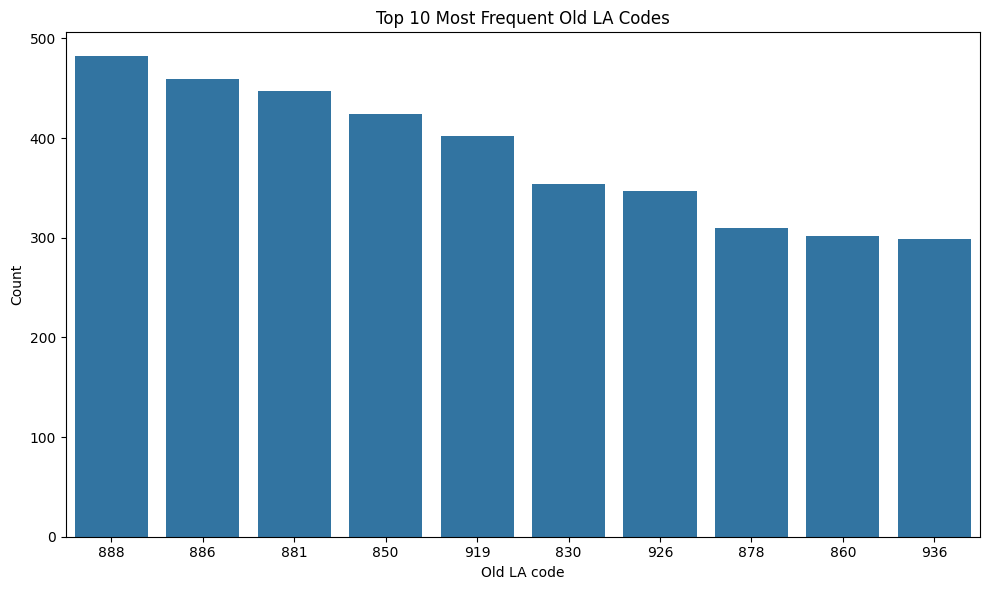

In [16]:
#Top 10 old LA codes with most schools
top_10_old_la_codes = pry_school_funding_data['old_la_code'].value_counts().nlargest(10).reset_index()
top_10_old_la_codes.columns = ['old_la_code', 'count']

top_10_old_la_codes = top_10_old_la_codes.sort_values(by='count', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_old_la_codes, x='old_la_code', y='count', order=top_10_old_la_codes['old_la_code'])

plt.title('Top 10 Most Frequent Old LA Codes')
plt.xlabel('Old LA code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most schools seem to be situated in local authorities with codes 888 and 886. From investigation, the names of 888 and 886 are *Lancashire and Kent*.

*New LA code*

The new LA codes are 9-character identifiers introduced by the Office for National Statistics (ONS) after the local government restructuring in 2009. These codes are used to reflect updated geography and are essential for administrative purposes like statistical reporting. The new codes start with letters indicating the country (e.g., 'E' for England), and are used in various systems to track local authority areas accurately.

In [17]:
#Checking unique values in new LA code column
pry_school_funding_data['new_la_code'].unique()

array(['E09000002', 'E09000003', 'E08000016', 'E06000022', 'E06000055',
       'E09000004', 'E08000025', 'E06000008', 'E06000009', 'E08000001',
       'E06000058', 'E06000036', 'E08000032', 'E09000005', 'E06000043',
       'E06000023', 'E09000006', 'E10000002', 'E08000002', 'E08000033',
       'E10000003', 'E09000007', 'E06000056', 'E06000049', 'E06000050',
       'E09000001', 'E06000052', 'E06000047', 'E08000026', 'E09000008',
       'E06000063', 'E06000005', 'E06000015', 'E10000007', 'E10000008',
       'E08000017', 'E06000059', 'E08000027', 'E09000009', 'E06000011',
       'E10000011', 'E09000010', 'E10000012', 'E08000020', 'E10000013',
       'E09000011', 'E09000012', 'E06000006', 'E09000013', 'E10000014',
       'E09000014', 'E09000015', 'E06000001', 'E09000016', 'E06000019',
       'E10000015', 'E09000017', 'E09000018', 'E06000046', 'E09000019',
       'E09000020', 'E10000016', 'E06000010', 'E09000021', 'E08000034',
       'E08000011', 'E09000022', 'E10000017', 'E08000035', 'E060

In [18]:
#Get number of new LA codes represented.
print(f"There are {len(pry_school_funding_data['new_la_code'].unique())} new LA codes represented")

There are 152 new LA codes represented


As expected the number of new LA codes matches exactly with that of the old LA codes. It would be useful to check and validate that each old LA code is ideally represented by its corresponding new LA code. The get information schools service (GISS) website provides a dataset that shows the new LA codes for old LA codes. We can utilize this dataset for our task.

In [19]:
#Reading dataset and renaming columns for easier analysis
la_codes_matching=pd.read_csv('data\old_la_codes_matching.csv')
la_codes_matching=la_codes_matching.rename(columns={'Get Information about Schools (GIAS) local authority (LA) code': 'old_la_code', 'Office for National Statistics (ONS) local authority (LA) code (also known as Government Statistical Service (GSS) local authority (LA) code on GIAS)': 'new_la_code'})

In [20]:
#First 10 rows
la_codes_matching.head(10)

,English local authority (LA) name,old_la_code,new_la_code
0,Barking and Dagenham,301,E09000002
1,Barnet,302,E09000003
2,Barnsley,370,E08000016
3,Bath and North East Somerset,800,E06000022
4,Bedford,822,E06000055
5,Bexley,303,E09000004
6,Birmingham,330,E08000025
7,Blackburn with Darwen,889,E06000008
8,Blackpool,890,E06000009
9,Bolton,350,E08000001


In [21]:
#Total LA codes in England
print(f"There are {len(la_codes_matching)} LA codes in England")

There are 184 LA codes in England


To check for correct matching, we will left merge both datasets on their old la codes' values and then check to see if values in both new la codes columns match.

In [22]:
#Merge both dataframes
df2 = pd.merge(pry_school_funding_data, la_codes_matching, on='old_la_code', how='left')
#Create a new column to check values, this column returns 0 if both values do not match and 1 if they do.
df2['new_la_code_matching'] = df2.apply(lambda row: 1 if row['new_la_code_x'] == row['new_la_code_y'] else 0, axis=1)


In [23]:
#Checking for count of mismatched new la codes
len(df2[df2['new_la_code_matching']==0])

895

There are close to 900 rows with new la codes that do not match those stated on the GISS website.

In [24]:
#Creating a new dataframe and viewing old la codes and la names with mismatch problem
mismatch_code=df2[df2['new_la_code_matching']==0]
print(mismatch_code['old_la_code'].unique())
print(mismatch_code['la_name'].unique())

[825 390 815 929 933]
['Buckinghamshire' 'Gateshead' 'North Yorkshire' 'Northumberland'
 'Somerset']


There seems to be a mismatch for *Buckinghamshire, Gateshead, North Yorkshire, Northumberland and Somerset*

Could it be that some la names of those mismatched have a different new la code?

In [25]:
#Checking to see if any sample of Buckinghamshire has a different new la code.
pry_school_funding_data['new_la_code'][(pry_school_funding_data['la_name']=='Buckinghamshire') & (pry_school_funding_data['new_la_code']!='E10000002')]

Series([], Name: new_la_code, dtype: object)

In [26]:
#Checking to see if any sample of Gateshead has a different new la code.
pry_school_funding_data['new_la_code'][(pry_school_funding_data['la_name']=='Gateshead') & (pry_school_funding_data['new_la_code']!='E08000020')]

Series([], Name: new_la_code, dtype: object)

In [27]:
#Checking to see if any sample of North Yorkshire has a different new la code.
pry_school_funding_data['new_la_code'][(pry_school_funding_data['la_name']=='North Yorkshire') & (pry_school_funding_data['new_la_code']!='E10000023')]

Series([], Name: new_la_code, dtype: object)

So far we can see there is a consistency in mismatch amongst the LAs with different new la codes. To resolve the problem, we could decide to replace the new la code column with that of the GISS website. Although the column may not be a huge determinant in model accuracy, for the sake of veracity, we will take this route.

In [28]:
#Mergr dataframe with codes matching data
pry_school_funding_data = pd.merge(pry_school_funding_data, la_codes_matching, on='old_la_code', how='left')


In [29]:
#Drop former new la code column as well as extra old la code column 
pry_school_funding_data.drop(['new_la_code_x','English local authority (LA) name'] , axis=1, inplace=True)
#Rename new la code column
pry_school_funding_data=pry_school_funding_data.rename(columns={'new_la_code_y': 'new_la_code'})


*LA name*


The column LA name provides the name for the constituency where the school is situated providing more info into the la codes previously analyzed. 

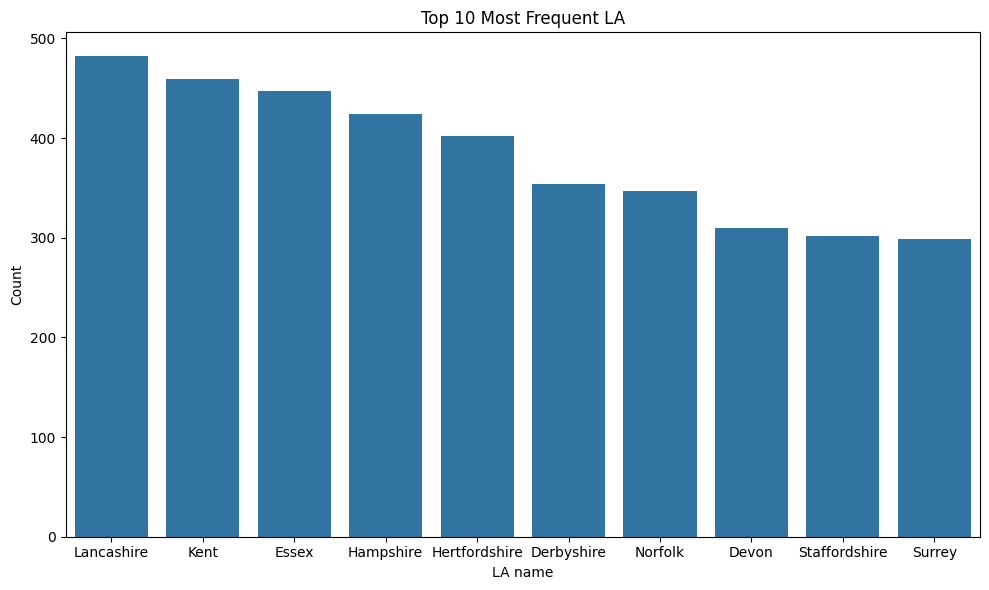

In [30]:
#Top 10 old LA  with most schools
top_10_old_la_codes = pry_school_funding_data['la_name'].value_counts().nlargest(10).reset_index()
top_10_old_la_codes.columns = ['la_name', 'count']

top_10_old_la_codes = top_10_old_la_codes.sort_values(by='count', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_old_la_codes, x='la_name', y='count', order=top_10_old_la_codes['la_name'])

plt.title('Top 10 Most Frequent LA')
plt.xlabel('LA name')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

These are similar to results seen in analysis of old la code column.

*School Type*


School type column gives information on the type of school being considered.

In [31]:
pry_school_funding_data['school_type'].value_counts()

school_type
Community school               5547
Academy converter              4889
Voluntary aided school         2301
Academy sponsor led            1676
Voluntary controlled school    1581
Foundation school               529
Free schools                    255
Name: count, dtype: int64

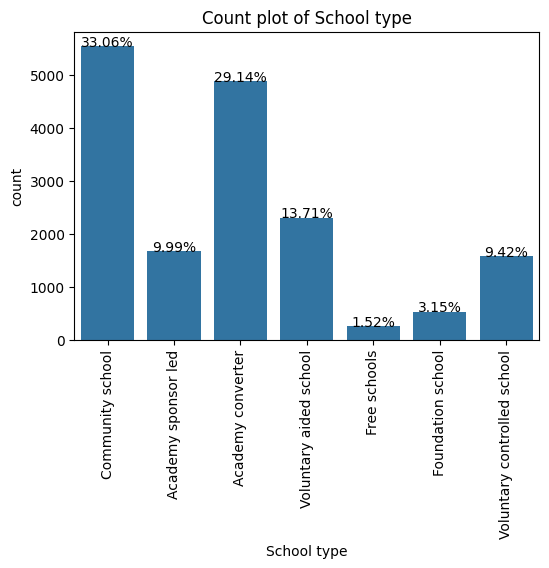

In [32]:
#Percentage of each transaction type in dataset visualized in a count plot
plt.figure(figsize=(6,4))
total=float(len(pry_school_funding_data['school_type']))
sen=sns.countplot(x='school_type', data=pry_school_funding_data)
for g in sen.patches:
    height=g.get_height()
    sen.text(g.get_x()+g.get_width()/2, height+3, '{:1.2f}%'.format((height/total)*100), ha='center')
plt.title('Count plot of School type')
plt.xlabel('School type')
plt.xticks(rotation=90)
plt.show()

Over 30% of schools are community schools, closely followed by academy converters which are high performance schools looking to become academies to gain autonomy.

*School Phase*


The school phase column gives information about the phase of education being offered by the school. Inour case, this is primary education.

In [33]:
#Values in school phase column
pry_school_funding_data['school_phase'].value_counts()

school_phase
Primary                  16770
Middle deemed primary        8
Name: count, dtype: int64

In addition to primary schools, we have schools in the middle deemed primary category. Middle deemed primary schools in the UK are middle schools classified as primary for administrative purposes. They typically teach pupils aged 9 to 13 (Years 5 to 8) but are treated like primary schools because they include Year 6. This classification affects how they're inspected, funded, and assessed, including participation in national SATs.

*Trust*

A school trust (often called a Multi-Academy Trust, or MAT) is a charitable company that manages one or more academy schools. These schools are state-funded but operate independently of the local authority. Board of trustees typically control staff pay, resource allocation and budgets as well as curriculum. Trusts are typically associated with academies. It would be useful to confirm this. Trust value of z corresponds to schools with no trustees. This can also be changed to 'No trustees' for clearer understanding.

In [34]:
#Replacing z values with 'No trustees'
pry_school_funding_data['trust'].replace({'z':'No trustees'}, inplace=True)
#Checking to see if there are schools without trust that are academies.
pry_school_funding_data[(pry_school_funding_data['trust']!='No trustees') & (pry_school_funding_data['academy']=='No')].head()

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\2771678762.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pry_school_funding_data['trust'].replace({'z':'No trustees'}, inplace=True)


,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,basic_entitlement_ks3,basic_entitlement_ks4,basic_entitlement_total_funding,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,deprivation_total_funding,eal_total_funding,mobility_total_funding,prior_attainment_total_funding,lump_sum_total_funding,sparsity_total_funding,london_fringe,split_site_total_funding,national_non_domestic_rates_funding,pfi_total_funding,exceptional_factors_total_funding,minimum_per_pupil_funding,total_schools_block_allocation_(pre_mfg),mfg_protection_or_capping_scaling,total_schools_block_allocation_(post_mfg),notional_sen,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,coronavirus_recovery_premium_funding,teachers_pay_additional_grant,mainstream_schools_additional_grant,national_tutoring_programme,total_funding,new_la_code


As expected we do not have schools that have boards of trustees and are not academies.

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\2363313234.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=top_10_trust_values, x='trust', y='count', order=top_10_trust_values['trust'], palette='blues_d')


ValueError: 'blues_d' is not a valid palette name

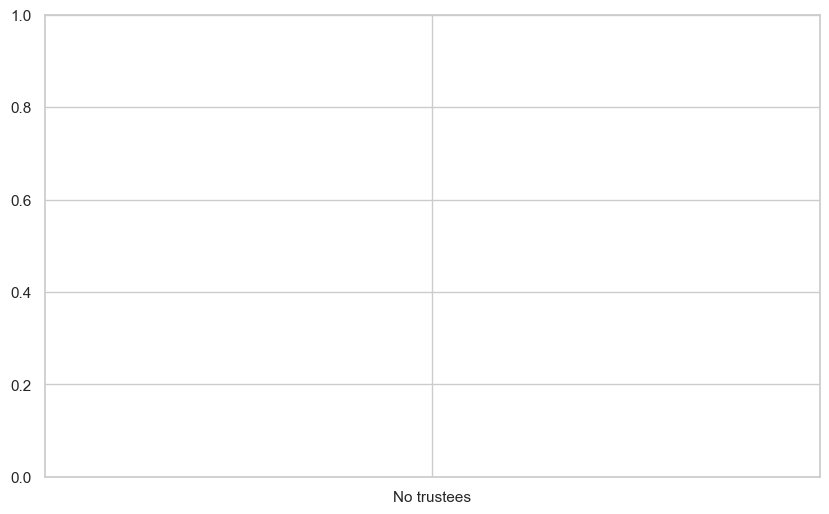

In [ ]:
#Visualizing Trust values
top_10_trust_values = pry_school_funding_data['trust'].value_counts().nlargest(10).reset_index()
top_10_trust_values.columns = ['trust', 'count']

top_10_trust_values = top_10_trust_values.sort_values(by='count', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
total=float(len(top_10_trust_values['trust']))
ax=sns.barplot(data=top_10_trust_values, x='trust', y='count', order=top_10_trust_values['trust'], palette='Blues_d')


for container in ax.containers:
    ax.bar_label(container)  
plt.title('Top 10 Trust values')
plt.xlabel('Trusts')
plt.ylabel('Count')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()



Close to 10000 schools of our sample size of 16000 do not have trustees. It would be useful to explore how this disparity affects funding. There's also a strong skew that would need to be accounted for.

In [36]:
pry_school_funding_data['trust'].value_counts()

trust
No trustees                                                                        9958
REACH2 ACADEMY TRUST                                                                 60
OXFORD DIOCESAN SCHOOLS TRUST                                                        42
BISHOP WILKINSON CATHOLIC EDUCATION TRUST                                            41
THE DIOCESE OF ELY MULTI-ACADEMY TRUST                                               39
THE DIOCESE OF NORWICH EDUCATION AND ACADEMIES TRUST                                 37
ASPIRE ACADEMY TRUST                                                                 36
THE BATH AND WELLS DIOCESAN ACADEMIES TRUST                                          36
GLF SCHOOLS                                                                          35
DELTA ACADEMIES TRUST                                                                34
BISHOP BEWICK CATHOLIC EDUCATION TRUST                                               34
UNITED LEARNING TRUST     

*Basic Entitlement Primary*

Basic Entitlement usually refers to the core curriculum time or funding guarantee that all students are entitled to receive, especially at key stages. We could plot a histogram to look at the distribution of values in this column.

Text(0.5, 0, 'Basic Entitlement Primary')

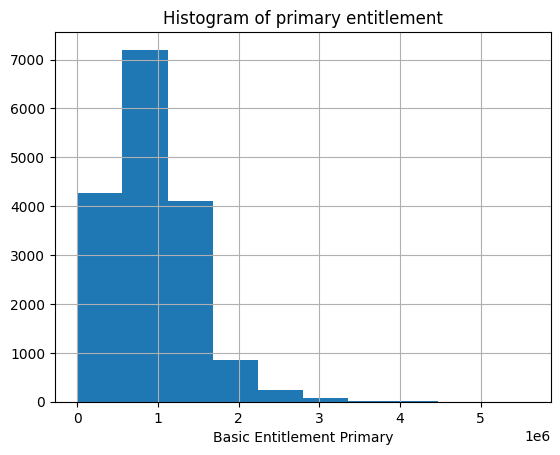

In [37]:
pry_school_funding_data['basic_entitlement_primary'].hist()
plt.title('Histogram of primary entitlement')
plt.xlabel('Basic Entitlement Primary')

There seems to be a slight right skew in our data. There are some outliers with higher primary entitlements. Let us see how the value of the median compares to the max value.

Text(0.5, 1.0, 'Box plot of Basic Entitlement Primary')

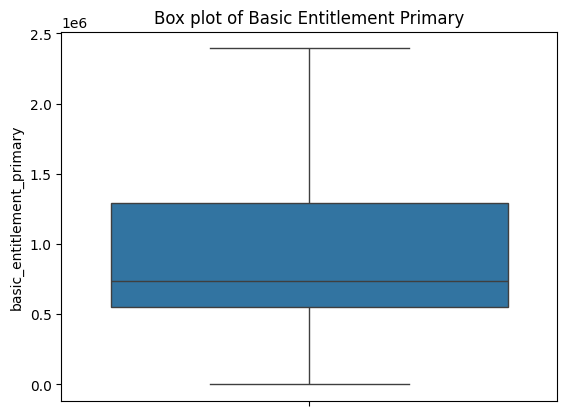

In [38]:
sns.boxplot(pry_school_funding_data['basic_entitlement_primary'], showfliers=False)
plt.title('Box plot of Basic Entitlement Primary')

In [39]:
pry_school_funding_data['basic_entitlement_primary'].median()

np.float64(735416.0)

In [40]:
pry_school_funding_data['basic_entitlement_primary'].max()

np.int64(5588935)

Compared to the median value of about 700000, we have a maximum value of over 5 million. In data cleaning for model building, it would be useful to deal with this inconsistency before the data is fed to the model. In addition, because basic entitlement is also dependent on number of pupils, it would be useful to explore the relationship between both features in multivariate analysis.

*FSM funding*

FSM stands for Free School Meals. FSM funding refers to extra money that schools in England, Wales, Scotland, and Northern Ireland receive to support children from low-income families who are eligible for free meals at school. It is important to not that it's not just the meal being funded — it’s extra money meant to close the attainment gap between disadvantaged pupils and their peers.

Text(0.5, 0, 'FSM funding')

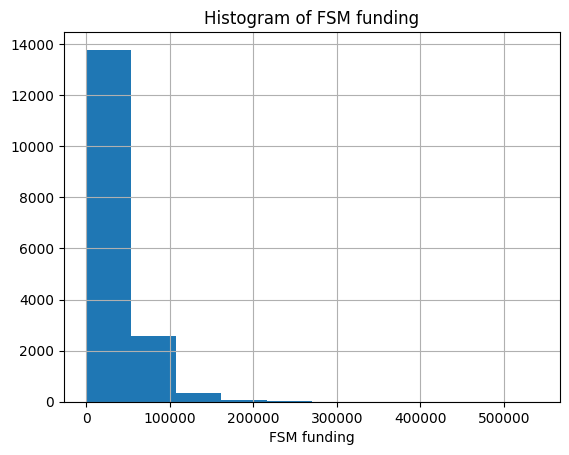

In [41]:
pry_school_funding_data['fsm_funding'].hist()
plt.title('Histogram of FSM funding')
plt.xlabel('FSM funding')

*IDACI bands*

IDACI (Income Deprivation Affecting Children Index) measures how deprived an area is based on the income of families with children, ranking small areas across England. In the dataframe, each IDACI Band (A–F) column shows the £ amount of funding the school receives for pupils living in areas of different deprivation levels (A = most deprived, F = least deprived). The idaci_funding column sums these amounts to give the school's total funding from IDACI.

IDACI Band | Description  
A | 0–10% most deprived 

B | 10–20% most deprived

C | 20–30% most deprived

D | 30–40% most deprived 

E | 40–50% most deprived
  
F | 50–60% most deprived 

Funds allocated to different bands are largely dependent on the number of students in the school that fall into the different bands.

Text(0.5, 0, 'IDACI funding')

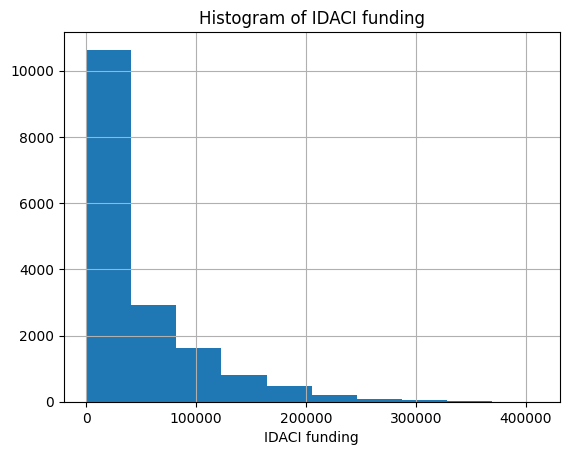

In [42]:
pry_school_funding_data['idaci_funding'].hist()
plt.title('Histogram of IDACI funding')
plt.xlabel('IDACI funding')

*Total number of pupils*

This simply represents the number of pupils prresent in each school. 

Text(0.5, 0, 'Number of pupils')

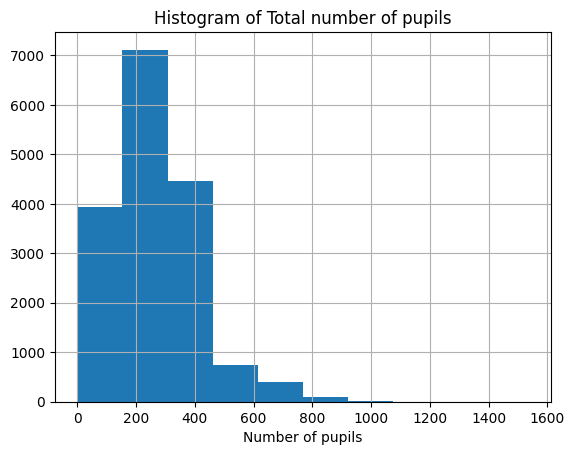

In [43]:
#Total number of pupils
pry_school_funding_data['total_number_of_pupils'].hist()
plt.title('Histogram of Total number of pupils')
plt.xlabel('Number of pupils')

From the plot, it would seem most schools have pupils within the range of 200 and 400 with some schools having over 800 pupils. According to the official statistics from the governement, average number of pupils in primary schools is about 281 so it would be useful to get an idea of these schools with over 800 pupils focusing on funding opportunities in such schoools.

In [44]:
print(f'There are {len(pry_school_funding_data[pry_school_funding_data["total_number_of_pupils"] > 800])} schools with over 800 pupils'
)

There are 84 schools with over 800 pupils


Ideally, schools with more students should receive more funding. These are factors to consider in multivariate analysis.

*Allocation Per Pupil*


Here, we analyze the total allocation per pupil for different schools.

Text(0.5, 0, 'Allocation per pupil')

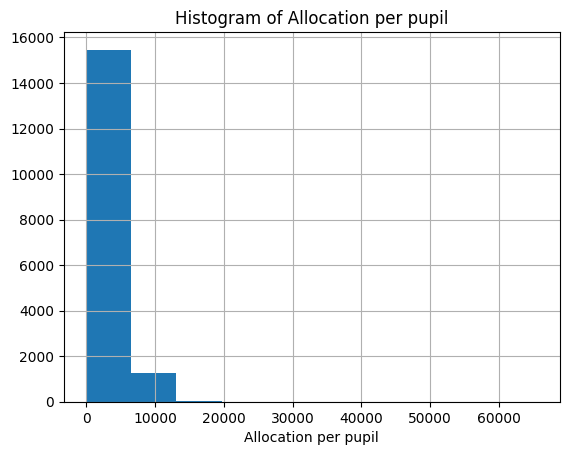

In [45]:
#Allocation per pupil
pry_school_funding_data['allocation_per_pupil'].hist()
plt.title('Histogram of Allocation per pupil')
plt.xlabel('Allocation per pupil')

Text(0.5, 1.0, 'Box plot of Allocation per pupil')

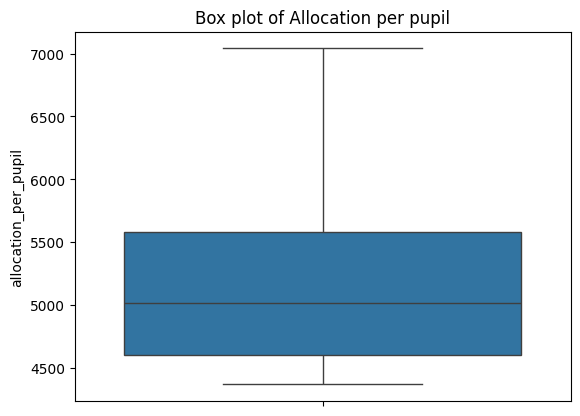

In [46]:
sns.boxplot(pry_school_funding_data['allocation_per_pupil'], showfliers=False)
plt.title('Box plot of Allocation per pupil')

Median allocation per pupil is about 5000 pounds.

*Pupil Premium*

The Pupil Premium is additional government funding given to publicly funded schools in England to raise the attainment of disadvantaged pupils and close achievement gaps between them and their peers.

It is provided for:
* Pupils who are (or have been) eligible for Free School Meals (FSM) in the last 6 years (FSM6)
* Children who are Looked After (in care)
* Children who have been Adopted from care
* Children of Armed Forces personnel (small separate premium)

Ideally we'd expect that the larger the FSM6 funding, the higher the Pupil Premium.

In [47]:
pry_school_funding_data['pupil_premium']=pry_school_funding_data['pupil_premium'].replace({'Not available': 0.0})

In [48]:
pry_school_funding_data['pupil_premium']=pry_school_funding_data['pupil_premium'].astype(float)

Text(0.5, 0, 'Pupil Premium')

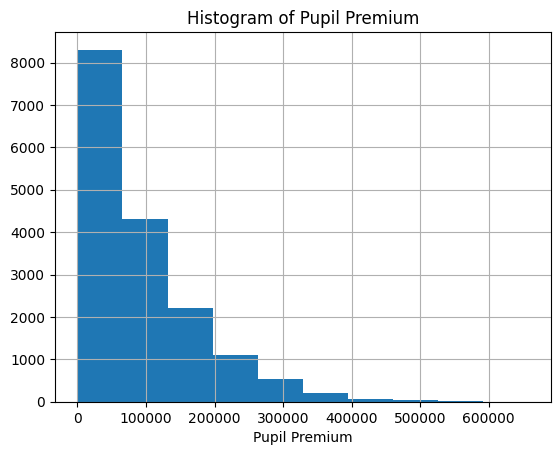

In [49]:
#Allocation per pupil
pry_school_funding_data['pupil_premium'].hist()
plt.title('Histogram of Pupil Premium')
plt.xlabel('Pupil Premium')

Distribution of pupil premium funds data is right skewed with some schools receiving funds close to 600000. Let us see some examples of those schools.

In [50]:
print(f'There are {len(pry_school_funding_data[pry_school_funding_data["pupil_premium"] > 500000])} schools with over 500000 in pupil premium funds '
)

There are 19 schools with over 500000 in pupil premium funds 


Text(0.5, 1.0, 'Box plot of Pupil Premium')

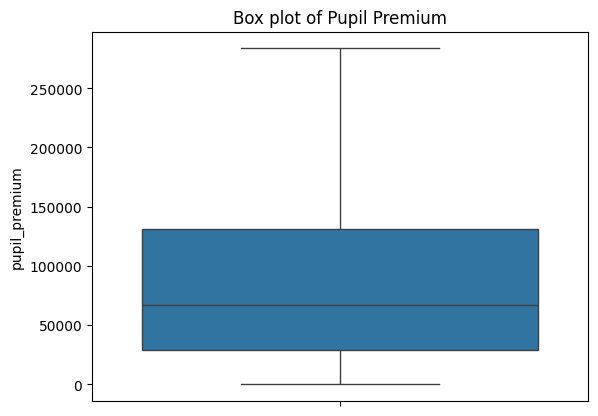

In [51]:
#Boxplot
sns.boxplot(pry_school_funding_data['pupil_premium'], showfliers=False)
plt.title('Box plot of Pupil Premium')

*Pupil Premium Pupils*


This describes the number of students that are benefactors of the pupil premium funds. It would be useful to explore the relationship between the funds allocated and the number of students. Ideally, we'd expect to see an increase in funds with a corresponding increase in students.

In [52]:
pry_school_funding_data['pupil_premium_pupils']=pry_school_funding_data['pupil_premium_pupils'].replace({'Not available': 0.0})

In [53]:
#Change column data type to int
pry_school_funding_data['pupil_premium_pupils']=pry_school_funding_data['pupil_premium_pupils'].astype(float)

Text(0.5, 1.0, 'Box plot of Pupil Premium Pupils')

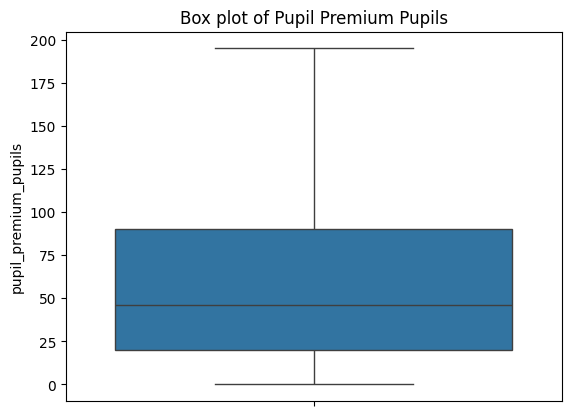

In [54]:
#Boxplot
sns.boxplot(pry_school_funding_data['pupil_premium_pupils'], showfliers=False)
plt.title('Box plot of Pupil Premium Pupils')

Median number of pupils who are beneficiaries of pupil premium funds is close to 50.

*Universal Free School Meals Grant*

The Universal Infant Free School Meals (UIFSM) grant is government funding that pays for all children in Reception, Year 1, and Year 2 (ages 4–7) in England to receive a free school meal, regardless of family income.
It’s different from Free School Meals (FSM), which are based on low-income eligibility.
Every child in those three year groups is automatically eligible for UIFSM — no means testing required.

In [55]:
pry_school_funding_data['universal_infant_free_school_meals_grant']=pry_school_funding_data['universal_infant_free_school_meals_grant'].replace({'z':0.00})

In [56]:
pry_school_funding_data['universal_infant_free_school_meals_grant']=pry_school_funding_data['universal_infant_free_school_meals_grant'].astype(float)

Text(0.5, 1.0, 'Box plot of UIFSM')

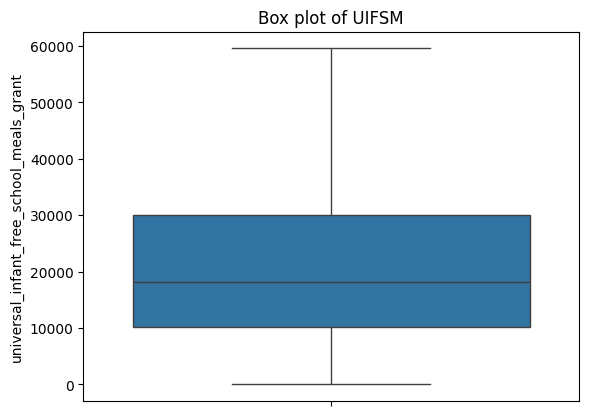

In [57]:
sns.boxplot(pry_school_funding_data['universal_infant_free_school_meals_grant'], showfliers=False)
plt.title('Box plot of UIFSM')

*PE & Sport Premium*

The PE and Sport Premium is additional funding provided to primary schools in England to improve physical education (PE), sport, and physical activity opportunities for pupils.
It is only for primary schools (not secondary).
Schools must use it to make sustainable improvements to their PE and sport provision — for example, by hiring specialist coaches, buying new sports equipment, or training staff.

In [58]:
pry_school_funding_data['pe_&_sport_premium']=pry_school_funding_data['pe_&_sport_premium'].replace({'z':0.00})

In [59]:
#Change column data type to float
pry_school_funding_data['pe_&_sport_premium']=pry_school_funding_data['pe_&_sport_premium'].astype(float)

Text(0.5, 0, 'PE & Sport Premium')

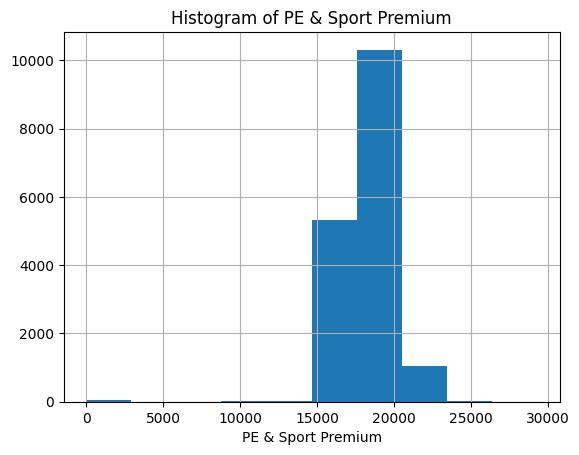

In [60]:
#PE & Sport Premium
pry_school_funding_data['pe_&_sport_premium'].hist()
plt.title('Histogram of PE & Sport Premium')
plt.xlabel('PE & Sport Premium')

The interesting shape of the histogram stems from the fact that we have schools who are not beneficiaries of the PE and Sport Premium funds and those who get over 25000 in PE and Sport funds.

In [61]:
pry_school_funding_data['pe_&_sport_premium_pupils']=pry_school_funding_data['pe_&_sport_premium_pupils'].replace({'z':0.00})

In [62]:
pry_school_funding_data['pe_&_sport_premium_pupils']=pry_school_funding_data['pe_&_sport_premium_pupils'].astype(int)

*Teachers Pay Additional Grant*

The Teachers' Pay Additional Grant was a top-up to help schools afford government-mandated teacher pay rises without having to cut other budgets.

In [63]:
pry_school_funding_data['teachers_pay_additional_grant']=pry_school_funding_data['teachers_pay_additional_grant'].replace({'z':0.00})

In [64]:
#Change column data type to float
pry_school_funding_data['teachers_pay_additional_grant']=pry_school_funding_data['teachers_pay_additional_grant'].astype(float)

Text(0.5, 0, 'teachers grant')

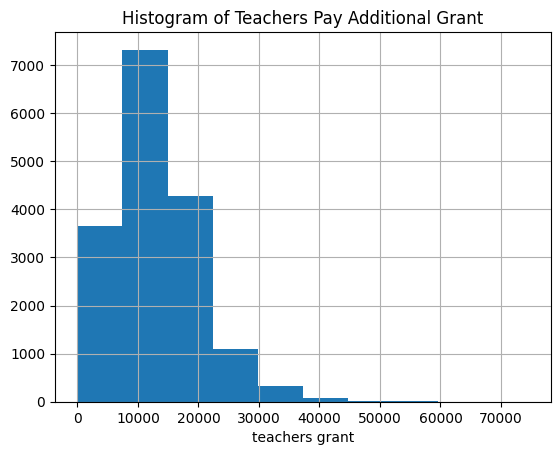

In [65]:
#PE & Sport Premium
pry_school_funding_data['teachers_pay_additional_grant'].hist()
plt.title('Histogram of Teachers Pay Additional Grant')
plt.xlabel('teachers grant')

*Total Funding*

Total funding represents a cumulative sum of all funds allocated to schools for the year 2023/2024.

Text(0.5, 0, 'total funding')

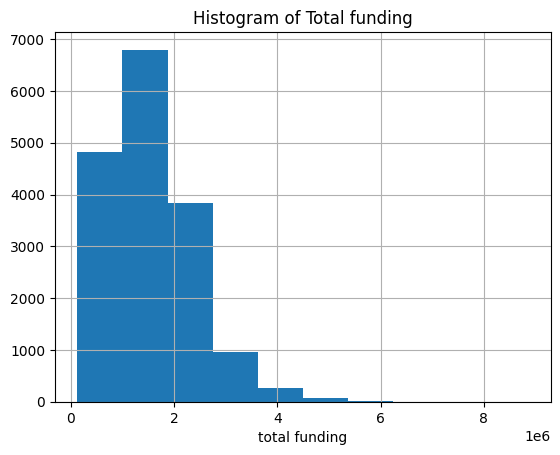

In [66]:
#PE & Sport Premium
pry_school_funding_data['total_funding'].hist()
plt.title('Histogram of Total funding')
plt.xlabel('total funding')

In [67]:
pry_school_funding_data['mainstream_schools_additional_grant']=pry_school_funding_data['mainstream_schools_additional_grant'].replace({'z':0.00})

In [68]:
pry_school_funding_data['mainstream_schools_additional_grant']=pry_school_funding_data['mainstream_schools_additional_grant'].astype(float)

In [69]:
pry_school_funding_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16778 entries, 0 to 16777
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   time_period                                16778 non-null  int64  
 1   time_identifier                            16778 non-null  object 
 2   geographic_level                           16778 non-null  object 
 3   country_code                               16778 non-null  object 
 4   country_name                               16778 non-null  object 
 5   old_la_code                                16778 non-null  int64  
 6   la_name                                    16778 non-null  object 
 7   school_ukprn                               16778 non-null  int64  
 8   school_urn                                 16778 non-null  int64  
 9   school_laestab                             16778 non-null  int64  
 10  school_name           

In [70]:
pry_school_funding_data[pry_school_funding_data['total_funding']=='z']

,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,basic_entitlement_ks3,basic_entitlement_ks4,basic_entitlement_total_funding,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,deprivation_total_funding,eal_total_funding,mobility_total_funding,prior_attainment_total_funding,lump_sum_total_funding,sparsity_total_funding,london_fringe,split_site_total_funding,national_non_domestic_rates_funding,pfi_total_funding,exceptional_factors_total_funding,minimum_per_pupil_funding,total_schools_block_allocation_(pre_mfg),mfg_protection_or_capping_scaling,total_schools_block_allocation_(post_mfg),notional_sen,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,coronavirus_recovery_premium_funding,teachers_pay_additional_grant,mainstream_schools_additional_grant,national_tutoring_programme,total_funding,new_la_code


We previously defined the scope of fundings to be considered in the study.
* pupil premiums
* meal allocations (FSM and UIFSM)
* family income(IDACI)
* teacher grants
* pe and sports premium
* basic entitlement

Now we go ahead to drop columns not necessary to our further analysis and model building.

In [71]:
#Dropping other columns
pry_school_funding_data=pry_school_funding_data.drop(columns=['basic_entitlement_ks3', 'basic_entitlement_ks4', 'basic_entitlement_total_funding', 'deprivation_total_funding', 'eal_total_funding',
       'mobility_total_funding', 'prior_attainment_total_funding',
       'lump_sum_total_funding', 'sparsity_total_funding', 'london_fringe',
       'split_site_total_funding', 'national_non_domestic_rates_funding',
       'pfi_total_funding', 'exceptional_factors_total_funding',
       'minimum_per_pupil_funding', 'total_schools_block_allocation_(pre_mfg)',
       'mfg_protection_or_capping_scaling',
       'total_schools_block_allocation_(post_mfg)', 'notional_sen','coronavirus_recovery_premium_funding', 'national_tutoring_programme'])

In [72]:
pry_school_funding_data.columns

Index(['time_period', 'time_identifier', 'geographic_level', 'country_code',
       'country_name', 'old_la_code', 'la_name', 'school_ukprn', 'school_urn',
       'school_laestab', 'school_name', 'school_type', 'school_phase', 'trust',
       'academy', 'basic_entitlement_primary', 'fsm_funding', 'fsm6_funding',
       'idaci_band_f', 'idaci_band_e', 'idaci_band_d', 'idaci_band_c',
       'idaci_band_b', 'idaci_band_a', 'idaci_funding',
       'total_number_of_pupils', 'allocation_per_pupil', 'pupil_premium',
       'pupil_premium_pupils', 'universal_infant_free_school_meals_grant',
       'pe_&_sport_premium', 'pe_&_sport_premium_pupils',
       'teachers_pay_additional_grant', 'mainstream_schools_additional_grant',
       'total_funding', 'new_la_code'],
      dtype='object')

In [73]:
pry_school_funding_data.head()

,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,teachers_pay_additional_grant,mainstream_schools_additional_grant,total_funding,new_la_code
0,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071309,101202,3012024,Beam Primary School,Community school,Primary,No trustees,No,2250199,76801,120002,20097,126778,24466,9804,0,0,181145,564,5783.971631,216795.0,149.0,46128.0,20740.0,474,29807.0,98865.0,3705550.0,E09000002
1,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071301,101231,3012068,Becontree Primary School,Community school,Primary,No trustees,No,1687649,52835,81601,27666,46390,54424,4902,579,0,133961,423,5731.340426,146955.0,101.0,33510.0,19610.0,361,22359.0,74160.0,2746323.5,E09000002
2,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071953,101188,3012005,Dorothy Barley Infants' School,Community school,Primary,No trustees,No,1033336,26690,39200,4192,23923,60148,16951,581,0,105795,259,6090.772201,71295.0,49.0,45847.0,17750.0,175,13830.0,45876.0,1782463.0,E09000002
3,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10045428,140687,3012002,Dorothy Barley Junior Academy,Academy sponsor led,Primary,REACH2 ACADEMY TRUST,Yes,1356503,63184,100001,6544,33142,73113,19120,0,763,132682,340,5742.864706,181875.0,125.0,0.0,19390.0,339,19813.0,65784.0,2268467.5,E09000002
4,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10056131,142699,3012006,Eastbury Primary School,Academy converter,Primary,PARTNERSHIP LEARNING,Yes,2984306,97500,155202,32103,73080,72898,13617,1157,0,192856,748,5491.457219,280815.0,193.0,63794.0,22440.0,644,38872.0,128906.0,4685461.5,E09000002


In [74]:
pry_school_funding_data.columns

Index(['time_period', 'time_identifier', 'geographic_level', 'country_code',
       'country_name', 'old_la_code', 'la_name', 'school_ukprn', 'school_urn',
       'school_laestab', 'school_name', 'school_type', 'school_phase', 'trust',
       'academy', 'basic_entitlement_primary', 'fsm_funding', 'fsm6_funding',
       'idaci_band_f', 'idaci_band_e', 'idaci_band_d', 'idaci_band_c',
       'idaci_band_b', 'idaci_band_a', 'idaci_funding',
       'total_number_of_pupils', 'allocation_per_pupil', 'pupil_premium',
       'pupil_premium_pupils', 'universal_infant_free_school_meals_grant',
       'pe_&_sport_premium', 'pe_&_sport_premium_pupils',
       'teachers_pay_additional_grant', 'mainstream_schools_additional_grant',
       'total_funding', 'new_la_code'],
      dtype='object')

**Bivariate and Multivariate analysis**

Beginning the multivariate and bivariate analyssi to explore the relationships between various features and their ultimate effects on the model. Checking for linear correlation between numerical features using pearson correlation.

<Axes: >

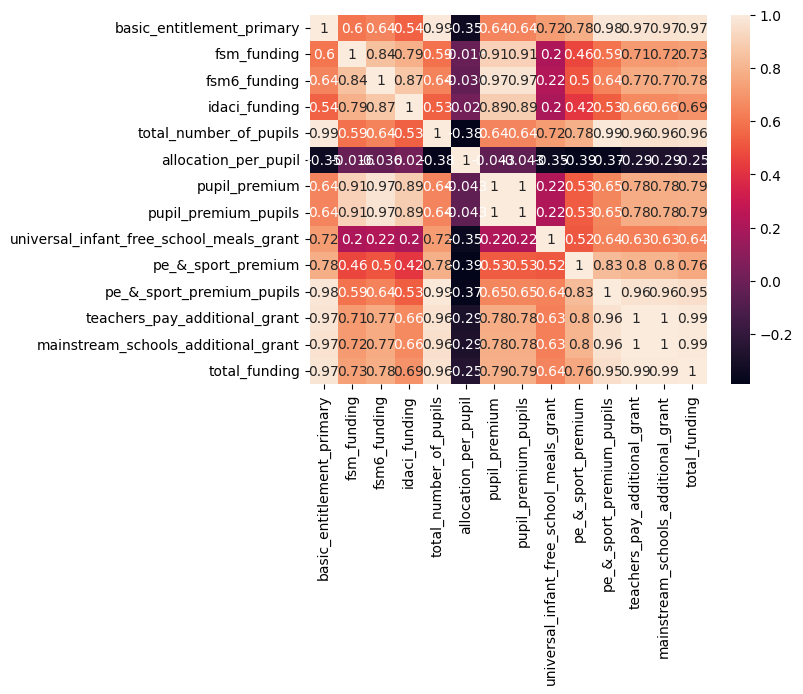

In [78]:
sns.heatmap(data=pry_school_funding_data[['basic_entitlement_primary', 'fsm_funding', 'fsm6_funding',
       'idaci_funding',
       'total_number_of_pupils', 'allocation_per_pupil', 'pupil_premium',
       'pupil_premium_pupils', 'universal_infant_free_school_meals_grant',
       'pe_&_sport_premium', 'pe_&_sport_premium_pupils',
       'teachers_pay_additional_grant', 'mainstream_schools_additional_grant',
       'total_funding']].corr(), annot=True)

From the heatmap:
* the column basic entitlement primary seems to possess a strong linear correlation with several columns including total funds, total number of pupils, pe & sport premium pupils, pe & sport premium, teacher's pay additional grant, mainstream schools additional grant and total funding.
* as expected there is a strong linear correlation between fsm funding and pupil premium and pupil premium pupils as well as between fsm6 and pupil premium and pupil premium pupils (like we expected in univariate analysis).
* there is also a strong positive correlation between total number of pupils and pe&sport premium pupils, teacher's pay additional grant, mainstream schools additional grant and total funding.

Because of multicollinaerity and its effect on models being developed, we would need to carry out extensive feature selection selecting either of the columns exhibiting strong linear correlation.


*School type vs Funding*

First of all, let us compare the primary basic entitlement allocated to schools based on their type.

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\4235848367.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pry_school_funding_data, x='school_type', y='basic_entitlement_primary', palette='Set2')


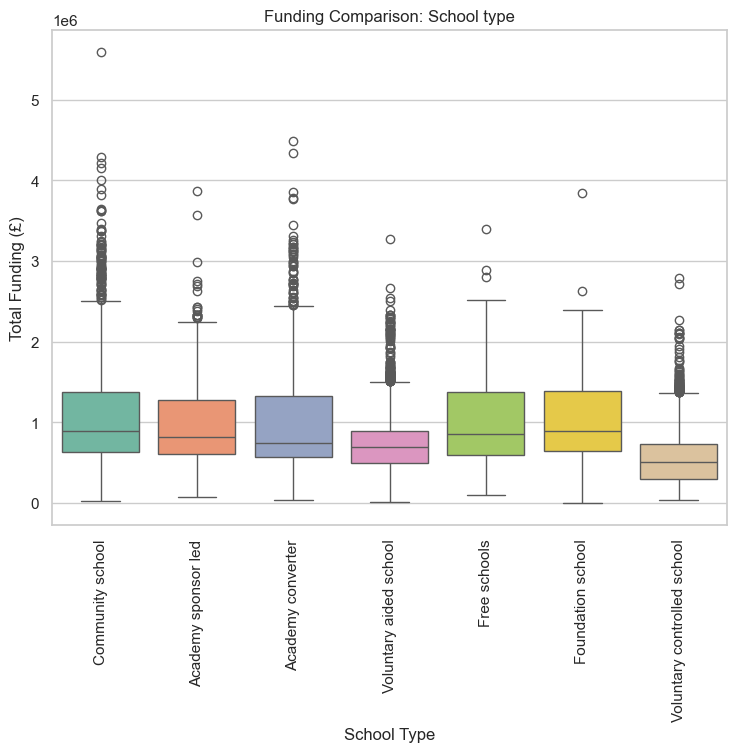

In [85]:
# Set the style
sns.set(style="whitegrid")

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=pry_school_funding_data, x='school_type', y='basic_entitlement_primary', palette='Set2')

# Add labels and title
plt.title('Funding Comparison: School type')
plt.xlabel('School Type')
plt.ylabel('Total Funding (£)')

# Optional: Rotate x-axis labels if needed
# plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

Voluntary aided and controlled schools seem to have a lower median primary basic entitlement than other school types. It would be useful to see how this is distributed across the pupils in terms of allocation per pupil.

*School type vs allocation per pupil*

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\1432019835.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pry_school_funding_data, x='school_type', y='allocation_per_pupil', palette='Set2', showfliers=False)


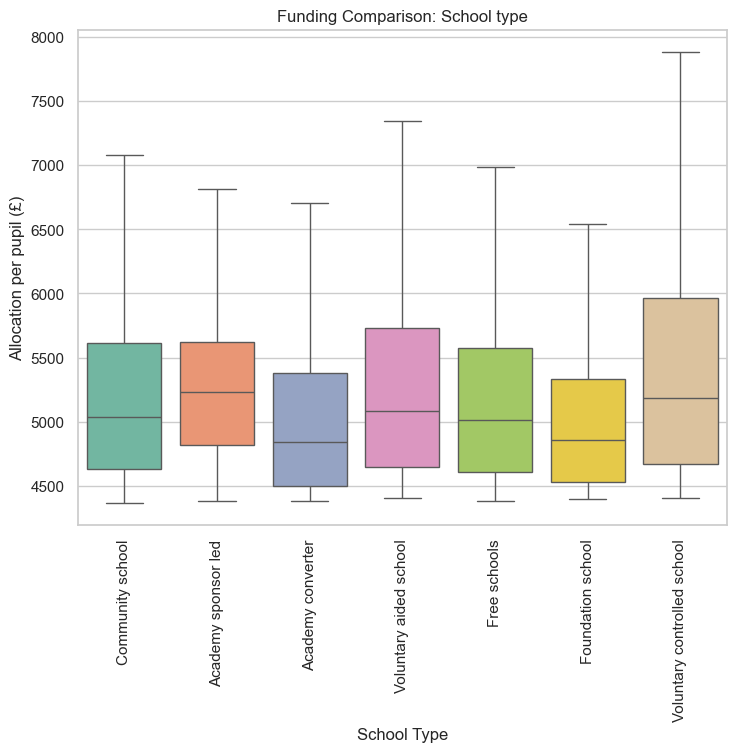

In [83]:
# Set the style
sns.set(style="whitegrid")

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=pry_school_funding_data, x='school_type', y='allocation_per_pupil', palette='Set2', showfliers=False)

# Add labels and title
plt.title('Funding Comparison: School type')
plt.xlabel('School Type')
plt.ylabel('Allocation per pupil (£)')

# Optional: Rotate x-axis labels if needed
# plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

While voluntary aided and controlled schools do not seem to be the most funded, they seem to however have one of the highest allocation per pupils of all school types. This could be attributed to several reasons from size of pupils, location of school and additional grants like fsm available.


Let us visualize the average number of students in each school type.

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\1716100178.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=grouped, x='school_type', y='total_number_of_pupils', palette='Blues_d')


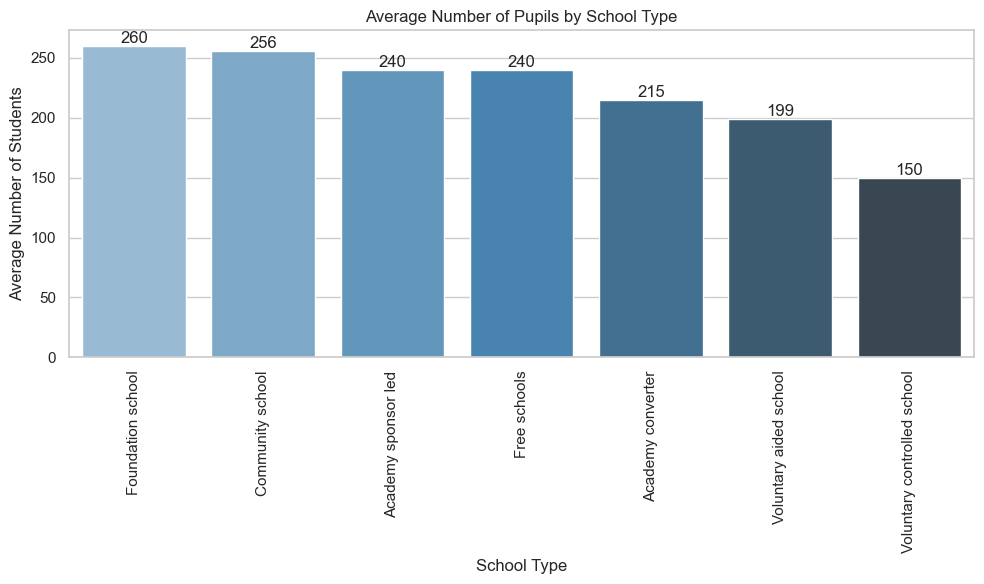

In [87]:
# Group by school type
grouped = pry_school_funding_data.groupby('school_type')['total_number_of_pupils'].median().reset_index()

# Sort values if desired (descending)
grouped = grouped.sort_values('total_number_of_pupils', ascending=False)

# Set plot style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(10, 6))
ax=sns.barplot(data=grouped, x='school_type', y='total_number_of_pupils', palette='Blues_d')

for container in ax.containers:
    ax.bar_label(container) 
# Add labels
plt.title('Average Number of Pupils by School Type')
plt.xlabel('School Type')
plt.ylabel('Average Number of Students')
plt.xticks(rotation=90)  # Rotate x labels if needed

plt.tight_layout()
plt.show()


Like we hypothesized, voluntary aided and controlled schools have the lowest average number of students and as such can allocate a higher funding amount to each pupil compared to other school types with more pupils.


School type vs IDACI funding

Let us gain insights into school types and their funding for income deprived pupils. This would help better understand the amount of pupils from income deprived pupils in certain school types.

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\224150197.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=grouped, x='school_type', y='idaci_funding', palette='Blues_d')


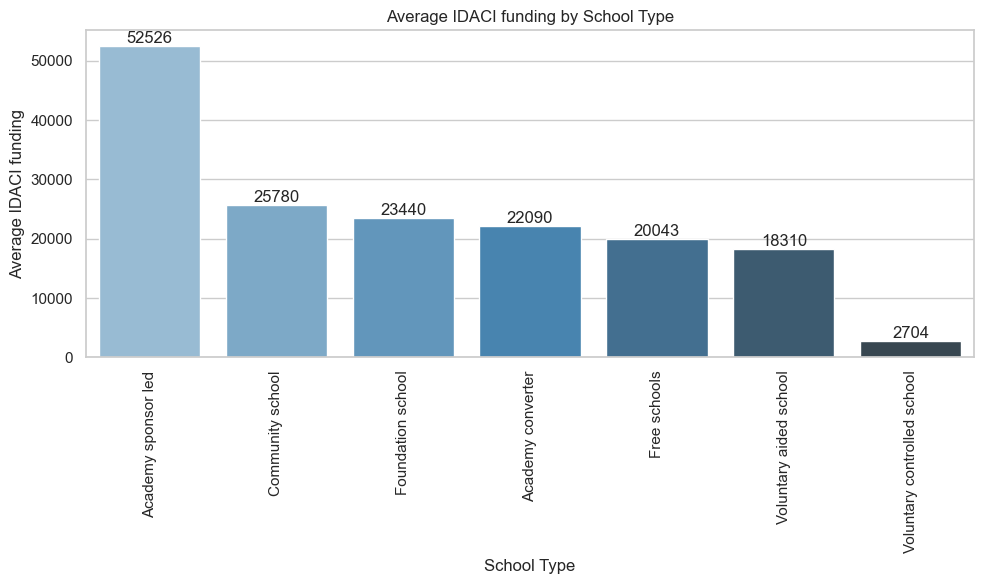

In [96]:
# Group by school type
grouped = pry_school_funding_data.groupby('school_type')['idaci_funding'].median().reset_index()

# Sort values if desired (descending)
grouped = grouped.sort_values('idaci_funding', ascending=False)

# Set plot style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(10, 6))
ax=sns.barplot(data=grouped, x='school_type', y='idaci_funding', palette='Blues_d')

for container in ax.containers:
    ax.bar_label(container) 
# Add labels
plt.title('Average IDACI funding by School Type')
plt.xlabel('School Type')
plt.ylabel('Average IDACI funding')
plt.xticks(rotation=90)  # Rotate x labels if needed

plt.tight_layout()
plt.show()


Academies seem to have the highest average IDACI brands. This occurs because they are situated in areas with low income indexes and are created to replace struggling schools in those communities. In addition, they are expected to have higher average fsm funding.

*Trust vs Funding*

Are schools with trust boards more funded than their counterparts with no funding?

In [93]:
#Create new column for trust
pry_school_funding_data['trust_or_no_trust']=pry_school_funding_data['trust'].apply(lambda x:0 if 'No trustees' in x else 1)

C:\Users\HP\AppData\Local\Temp\ipykernel_15852\3062048419.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=grouped, x='trust_or_no_trust', y='total_funding', palette='Blues_d')


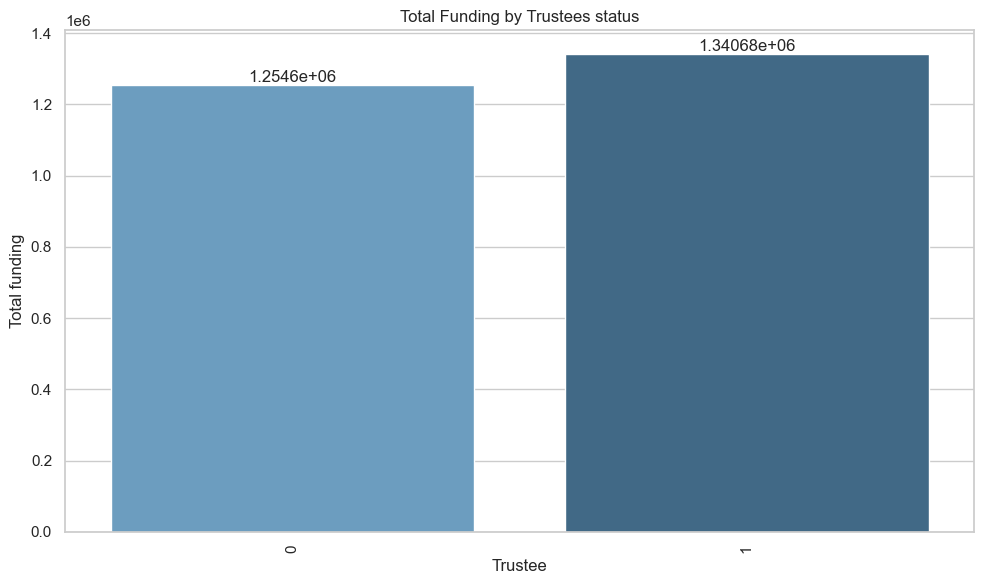

In [95]:
# Group by school type
grouped = pry_school_funding_data.groupby('trust_or_no_trust')['total_funding'].median().reset_index()

# Sort values if desired (descending)
grouped = grouped.sort_values('total_funding', ascending=False)

# Set plot style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(10, 6))
ax=sns.barplot(data=grouped, x='trust_or_no_trust', y='total_funding', palette='Blues_d')

for container in ax.containers:
    ax.bar_label(container) 
# Add labels
plt.title('Total Funding by Trustees status')
plt.xlabel('Trustee')
plt.ylabel('Total funding')
plt.xticks(rotation=90)  # Rotate x labels if needed

plt.tight_layout()
plt.show()


There is a substantial difference in average funding of schools with a board of trustees and those that do not possess one.

**ks2 data**

The KS2 (Key Stage 2) metric refers to the performance measures used to assess pupils aged 7–11 in England, typically in Year 6. These metrics are crucial for evaluating school effectiveness at the end of primary education.
Typically the ks2 metric measures pupils's abailities in three categories namesly: 
* Reading
* Writing
* Mathematics.


For the sake of our analysis, we will be creating a single metric representing an average of the three categories being considered in the ks2 test i.e, reading, writing and mathematics.
We will thus be utilizing three columns:
* READ_AVERAGE- Average scaled score in reading
* GPS_AVERAGE- Average scaled score in grammar, punctuation and spelling
* MAT_AVERAGE- Average scaled score in maths

Because the other columns are not very important to us, we can drop them and keep the three specified.

In [102]:
columns_to_keep=['RECTYPE', 'LEA', 'URN', 'SCHNAME', 'READ_AVERAGE', 'GPS_AVERAGE', 'MAT_AVERAGE']
ks2_data=ks2_data[columns_to_keep]

In [103]:
ks2_data.head()

,RECTYPE,LEA,URN,SCHNAME,READ_AVERAGE,GPS_AVERAGE,MAT_AVERAGE
0,1,353.0,136223.0,Hodge Clough Primary School,102,102,101
1,1,821.0,109579.0,Icknield Primary School,105,106,104
2,1,821.0,142263.0,St Margaret of Scotland Catholic Primary School,106,108,105
3,2,821.0,109745.0,Lady Zia Wernher School,NaN,NaN,NaN
4,1,822.0,109436.0,Priory Primary School,103,105,103


In [105]:
ks2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16637 entries, 0 to 16636
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RECTYPE       16637 non-null  int64  
 1   LEA           16635 non-null  float64
 2   URN           16482 non-null  float64
 3   SCHNAME       16635 non-null  object 
 4   READ_AVERAGE  15806 non-null  object 
 5   GPS_AVERAGE   15791 non-null  object 
 6   MAT_AVERAGE   15806 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 910.0+ KB


Looks like we have some null values in the URN value. We could replace the null values with 0 for a start.

In [112]:
#Fill null URN with 0
ks2_data['URN']=ks2_data['URN'].fillna(0)

In [113]:
#Change data type of URN
ks2_data['URN']=ks2_data['URN'].astype(int)

In [115]:
#Rename URN to school_urn
ks2_data=ks2_data.rename(columns={'URN': 'school_urn'})

Next we can join both dataframes on the URN column.

In [ ]:
#Merging both dataframes
final_df= pd.merge(pry_school_funding_data, ks2_data, on='school_urn', how='left')

Looking for schools with no values for ks2 metrics.

In [ ]:
#How many schools are not represented
len(final_df[final_df['READ_AVERAGE'].isna()])

1810

We have over 1800 schools with no matching data on the ks2 metrics.Best steps might be to drop these rows as they might not affect our model's accuracy.

In [123]:
#Dropping null values
final_df=final_df.dropna(subset=['READ_AVERAGE'])

In [126]:
#Confirming we do not have any null values
final_df.isna().sum()

time_period                                 0
time_identifier                             0
geographic_level                            0
country_code                                0
country_name                                0
old_la_code                                 0
la_name                                     0
school_ukprn                                0
school_urn                                  0
school_laestab                              0
school_name                                 0
school_type                                 0
school_phase                                0
trust                                       0
academy                                     0
basic_entitlement_primary                   0
fsm_funding                                 0
fsm6_funding                                0
idaci_band_f                                0
idaci_band_e                                0
idaci_band_d                                0
idaci_band_c                      

In [127]:
final_df.head()

,time_period,time_identifier,geographic_level,country_code,country_name,old_la_code,la_name,school_ukprn,school_urn,school_laestab,school_name,school_type,school_phase,trust,academy,basic_entitlement_primary,fsm_funding,fsm6_funding,idaci_band_f,idaci_band_e,idaci_band_d,idaci_band_c,idaci_band_b,idaci_band_a,idaci_funding,total_number_of_pupils,allocation_per_pupil,pupil_premium,pupil_premium_pupils,universal_infant_free_school_meals_grant,pe_&_sport_premium,pe_&_sport_premium_pupils,teachers_pay_additional_grant,mainstream_schools_additional_grant,total_funding,new_la_code,trust_or_no_trust,RECTYPE,LEA,SCHNAME,READ_AVERAGE,GPS_AVERAGE,MAT_AVERAGE
0,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071309,101202,3012024,Beam Primary School,Community school,Primary,No trustees,No,2250199,76801,120002,20097,126778,24466,9804,0,0,181145,564,5783.971631,216795.0,149.0,46128.0,20740.0,474,29807.0,98865.0,3705550.0,E09000002,0,1.0,301.0,Beam Primary School,109,112,108
1,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10071301,101231,3012068,Becontree Primary School,Community school,Primary,No trustees,No,1687649,52835,81601,27666,46390,54424,4902,579,0,133961,423,5731.340426,146955.0,101.0,33510.0,19610.0,361,22359.0,74160.0,2746323.5,E09000002,0,1.0,301.0,Becontree Primary School,105,107,106
3,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10045428,140687,3012002,Dorothy Barley Junior Academy,Academy sponsor led,Primary,REACH2 ACADEMY TRUST,Yes,1356503,63184,100001,6544,33142,73113,19120,0,763,132682,340,5742.864706,181875.0,125.0,0.0,19390.0,339,19813.0,65784.0,2268467.5,E09000002,1,1.0,301.0,Dorothy Barley Junior Academy,104,105,103
4,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10056131,142699,3012006,Eastbury Primary School,Academy converter,Primary,PARTNERSHIP LEARNING,Yes,2984306,97500,155202,32103,73080,72898,13617,1157,0,192856,748,5491.457219,280815.0,193.0,63794.0,22440.0,644,38872.0,128906.0,4685461.5,E09000002,1,1.0,301.0,Eastbury Primary School,103,106,104
5,202324,Financial year,School,E92000001,England,301,Barking and Dagenham,10072898,101228,3012065,Five Elms Primary School,Community school,Primary,No trustees,No,1635783,73533,115201,23286,63385,12513,17473,11023,0,127679,410,5739.365854,208065.0,143.0,28743.0,19620.0,362,23306.0,77361.0,2743621.5,E09000002,0,1.0,301.0,Five Elms Primary School,105,108,105


In [129]:
#Save final dataframe to a new csv file
final_df.to_csv('data/funding_model.csv')

Now we begin feature selection and engineering.
